# Exploration of datasets

In [1]:
import os, sys
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from genai_detection.detectors.impostor import ImpostorDetector
from genai_detection.visualization import datasets
from genai_detection.config import CONFIG
from functools import partial
import gc
import datetime
import textwrap
import pyreadstat
import collections
from datasets import load_from_disk

[nltk_data] Downloading package punkt_tab to /Users/klara/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
def print_min_len_text_sample(df):
    df["text_length"] = df["pair"].apply(
        lambda x: min(len(x[0].split()), len(x[1].split()))
    )
    min_len_texts = df[df["text_length"] == min(df["text_length"])]
    shorter_text = min(min_len_texts["pair"].values[0], key=lambda t: len(t.split()))
    print(
        f"Text with minimal length {len(shorter_text.split())}:\n{textwrap.fill(shorter_text, width=100)}\n"
    )


def print_max_len_text_sample(df):
    df["text_length"] = df["pair"].apply(
        lambda x: min(len(x[0].split()), len(x[1].split()))
    )
    max_len_texts = df[df["text_length"] == max(df["text_length"])]
    longer_text = max(max_len_texts["pair"].values[0], key=lambda t: len(t.split()))
    print(
        f"Text with maximal length {len(longer_text.split())}:\n{textwrap.fill(longer_text, width=100)}"
    )


def _split(text):
    """Split text into sentences."""
    return text.split(" ")

# Cross-genre dataset

In [ ]:
# %pip install datasets==4.0.0 --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
artificial-authorship-verification 0.1.0 requires llm-detector@ git+https://github.com/KlaraGtknst/MirrorMinds-LLMDetector.git@refactor/modul, which is not installed.
generative-ai-detection 0.1.0 requires datasets<4.0.0,>=3.1.0, but you have datasets 4.0.0 which is incompatible.
artificial-authorship-verification 0.1.0 requires datasets<4.0.0,>=3.1.0, but you have datasets 4.0.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import datasets

print(datasets.__version__)

4.0.0


In [3]:
path2cross_genre = Path(os.getcwd()).resolve().parent / CONFIG.PATH2CROSS_GENRE
assert (
    path2cross_genre.exists()
), f"Path {path2cross_genre} to student essays dataset does not exist."
dataset = load_from_disk(path2cross_genre)
for split in dataset.keys():
    print(f"Split: {split}")
    df = dataset[split].to_pandas()
    # print(df.head())
    print(f"Number of samples: {len(df)}")
    authors = [a for r in df["authors"] for a in r]
    print(f"Number of unique authors: {collections.Counter(authors)}")
    print(f"Number of unique texts: {collections.Counter(df['category'])}")
    print(f"Number of unique labels: {collections.Counter(df['same'])}")

Split: train
Number of samples: 49
Number of unique authors: Counter({'William Shakespeare': 7, 'Ben Jonson': 5, '3836992': 4, 'CBL278': 3, '99275': 2, '1274852': 2, 'MJK677': 2, '4187605': 2, '3829823': 2, '324635': 2, '4079126': 2, '19506': 2, '1912828': 2, '610733': 2, '297186': 2, '3559329': 2, '2345236': 2, 'JPH453': 2, '3334775': 2, '1960766': 2, '823780': 2, '3429167': 2, 'TYP58': 2, 'CL2373': 2, '3735417': 1, '3043495': 1, 'DNS336': 1, 'AMP987': 1, 'openai-gpt-oss-120b': 1, '3128388': 1, '2413978': 1, '3848455': 1, '1938290': 1, 'TER297': 1, 'CMF682': 1, '6470281': 1, '670562': 1, 'AG6374': 1, 'AHC284': 1, '1063313': 1, '2190377': 1, 'EBW229': 1, '4495794': 1, 'BulletPoint': 1, '4242073': 1, '2598246': 1, '3347': 1, '1071383': 1, 'AJD479': 1, 'DFK73': 1, '2156086': 1, '1499171': 1, '3893998': 1, '4007024': 1, '585855': 1, '2948753': 1, '4711692': 1, '1202429': 1, 'qwen3-32b': 1, '3232275': 1, '1728017': 1, 'G_1159929665': 1, 'SRG495': 1})
Number of unique texts: Counter({'Pan 2

# Student Essay Dataset

In [3]:
path2student_essays = (
    Path(os.getcwd()).resolve().parent / CONFIG.DATA_BASE_PATH / "student_essays/"
)
assert (
    path2student_essays.exists()
), f"Path {path2student_essays} to student essays dataset does not exist."
sav_files = list(path2student_essays.rglob("*.sav"))
assert len(sav_files) > 0, f"No .sav files found in {path2student_essays}."
for file in sav_files:
    assert file.exists(), f"File {file} does not exist."
    # print(f"\n=== {file.name} ===")
    df, meta = pyreadstat.read_sav(file, apply_value_formats=True, metadataonly=False)
    # display(df)   # Uncomment to display the dataframe in Jupyter Notebook, do not commit because sensitive data

In [4]:
import chardet

# build student essays dataset
student_essays_df = pd.DataFrame(
    columns=["author_id", "text", "task", "task_description"]
)
task_description = {
    "Ass1": "Stream of consciousness",
    "Ass2": "Talk about your childhood",
    "Ass3": "Describe your personality",
    "Ass4": "Thematic Apperception Test",
    "Ass5": "Give four examples of four different theories",
}
# iterate over all TXT files in assignment directories and extract the essays
for dir in [f"Ass{i}" for i in range(1, 6)]:
    path2ass_dir = (
        Path(os.getcwd()).resolve().parent
        / CONFIG.DATA_BASE_PATH
        / "student_essays/Intro2006"
        / dir
    )
    assert (
        path2ass_dir.exists()
    ), f'Path {path2ass_dir} to Assignment "{task_description[dir]}" of student essays dataset does not exist.'

    if dir == "Ass5":  # has subtasks (directories)
        text_files = []
        for subtask in path2ass_dir.iterdir():
            text_files.extend(subtask.glob("*.txt"))
    else:
        text_files = path2ass_dir.glob("*.txt")

    for txt_file in text_files:
        with open(txt_file, "rb") as f:
            raw_data = f.read()
            detected = chardet.detect(raw_data)
            encoding = detected["encoding"]

        essay_text = raw_data.decode(encoding)
        student_essays_df = pd.concat(
            [
                student_essays_df,
                pd.DataFrame(
                    [
                        {
                            "author_id": txt_file.stem,
                            "text": essay_text,
                            "task": txt_file.parent.name,
                            "task_description": task_description[dir],
                        }
                    ]
                ),
            ]
        )

display(student_essays_df)

# metadata dataframe
author_metadata_columns = [
    "ID",
    "TEACHER",
    "BIRTHORD",
    "SEX",
    "ETHNIC",
    "POLITOR",
    "YEAR",
]
rename_map = {
    "ID": "author_id",
    "TEACHER": "teacher",
    "BIRTHORD": "birthorder",
    "SEX": "sex",
    "ETHNIC": "ethnicity",
    "POLITOR": "political_orientation",
    "YEAR": "year",
}
raw_metadata, _ = pyreadstat.read_sav(
    Path(os.getcwd()).resolve().parent
    / CONFIG.DATA_BASE_PATH
    / "student_essays/Intro2006/2006Big5xxx.sav",
    apply_value_formats=True,
    metadataonly=False,
)
available_columns = [
    col for col in raw_metadata.columns if col in author_metadata_columns
]
author_metadata = raw_metadata[available_columns].copy()
author_metadata.rename(columns=rename_map, inplace=True)
# keep NaNs, no answer is also an answer group
display(author_metadata)

,author_id,text,task,task_description
0,2006_EFB232,I come from a small town on the coast of Texas...,Ass1,Stream of consciousness
0,2006_VBC75,"Alright, so the first thought in my head is wo...",Ass1,Stream of consciousness
0,2006_SMY244,I don't know why this kind of stuff always hap...,Ass1,Stream of consciousness
0,2006_MM22236,I feel very full at the present time. I had no...,Ass1,Stream of consciousness
0,2006_AUSTINKW,My name is Kyle Austin and my EID is austinkw....,Ass1,Stream of consciousness
...,...,...,...,...
0,JWJ296,My stepmother is extremely prone to committing...,Ass5a,Give four examples of four different theories
0,JDP2276,An example of the fundamental attribution erro...,Ass5a,Give four examples of four different theories
0,CEG588,The only thing I can think of that relates to ...,Ass5a,Give four examples of four different theories
0,KAM2437,Every once in a while I would run into a girl ...,Ass5a,Give four examples of four different theories


,author_id,teacher,sex,ethnicity,birthorder,political_orientation,year
0,144332,Gosling,female,Hispanic,oldest,middle,2.0
1,AA8763,Pennebaker,male,other,oldest,NaN,1.0
2,AAA958,Gosling,female,Hispanic,oldest,middle,1.0
3,AAH683,Pennebaker,male,Asian Amer,second,ext cons,1.0
4,AAH699,Pennebaker,female,Asian Amer,oldest,middle,1.0
...,...,...,...,...,...,...,...
1042,ZH523,Pennebaker,male,Asian Amer,oldest,som lib,3.0
1043,ZL374,Gosling,female,Hispanic,oldest,som lib,2.0
1044,ZLL62,Pennebaker,male,Asian Amer,oldest,ext lib,1.0
1045,ZRP68,Gosling,male,White,oldest,som cons,1.0


In [5]:
# display(student_essays_df[student_essays_df.task=="Ass5a"] )
# display(student_essays_df[student_essays_df.task=="Ass5b"] )
# display(student_essays_df[student_essays_df.task=="Ass5c"] )
# display(student_essays_df[student_essays_df.task=="Ass5d"] )

In [6]:
student_essays = datasets.StudentEssaysVisualization()
ds_student_essays = student_essays.load_dataset()
labels_student_essays = ds_student_essays["same"]
display(ds_student_essays.head())

,pair,authors,same
0,"[My early childhood life was filled with love,...","[MKW429, MKW429]",True
1,"[Childhood. Ah, what a topic. Where do you beg...","[JAL2326, JAL2326]",True
2,"[ever since I was younger, I have been closer ...","[YK2372, YK2372]",True
3,[I have always been very close to my family. W...,"[LWB228, LWB228]",True
4,[I truly believe that people think of themselv...,"[EAM786, EAM786]",True


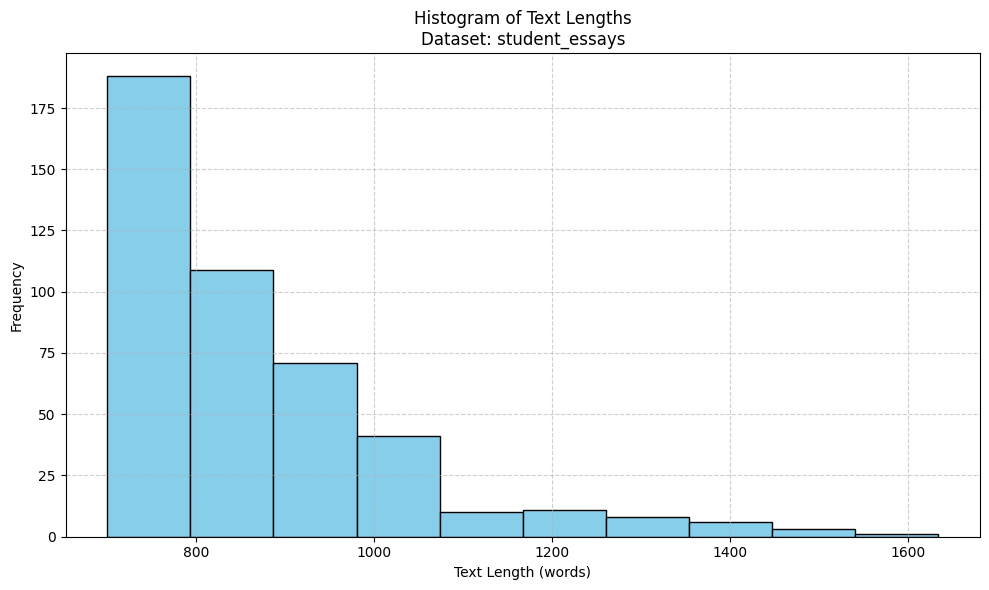

Average length (characters) per text: 865.90


In [7]:
student_essays.plot_text_length_histogram(
    dataset=ds_student_essays, preprocess_fn=_split, unit="words"
)

In [8]:
student_essays_stats = student_essays.dataset_stats()

Display texts of minimal and maximal length from the student essay dataset.

The shortest Student Essay text (500 words) is a (fictional) story about theft of experiment results with a happy ending.

In [9]:
print_min_len_text_sample(ds_student_essays)

Text with minimal length 700:
Early in life relationships was just party of growing up. In a family of five kids I always had
someone to play with or bug. My relationship with my oldest brother compaired to my younger brother,
however, was and is very different. Only within the past 4 years have I really gotten to know my
oldest brother. He is just over 7 years older than me and my little brother is just under 5 years
younger than me. I never thought I would know my oldest brother very well because he was in high
school, college, then gone around the times when I really remember growing up. Then he moved back
and my parents moved away with only a year and a half of high school left. So, I got to live with
him for the last year and a half of high school. It was great because I became much closer with him
and I didn't have to live with my parents. My relationship with my parents before this were pretty
normal. I was developing a temper with my mom more and more because she would ask such

The longest Student Essay text (1136 words) is a text about the inner thoughts of a person who seems to think he is manipulative and hurts women without them knowing it after a breakup.

In [10]:
print_max_len_text_sample(ds_student_essays)

Text with maximal length 1380:
I realize that experiences from the past influence who a person is today. All my life I've tried to
analyze who I am and why I do the things I do. It's hard for me to pick apart the pieces to my life
when in my mind I have already pieced them together. As a child I lived in a typical family, a mom,
a dad, a brother, and numerous relatives. My brother was five years older than me so as a child we
did not necessarily relate on a social level. He was too much older than me. Our relationship
consisted more of the typical fighting between a big brother and a little sister. I guess the
protection factor played in to. During the days, after school and such, my grandmother kept me. She
babysat my little cousin and I from when we weren't even in school until we could finally stay by
ourselves at home. My grandmother even picked me up from school until I got my driver's license as a
sophomore. She was a great grandmother. When me and my cousin Christopher played (h

In [11]:
# ds_student_essays["text_length"] = ds_student_essays["pair"].apply(lambda x: min(len(x[0].split()), len(x[1].split())))
# min_len_texts = ds_student_essays[ds_student_essays["text_length"] == min(ds_student_essays["text_length"])]
# shorter_text = min(min_len_texts['pair'].values[0], key=lambda t: len(t.split()))
# # print(f"Text with minimal length {len(shorter_text.split())}:\n{textwrap.fill(shorter_text, width=100)}\n")

# max_len_texts = ds_student_essays[ds_student_essays["text_length"] == max(ds_student_essays["text_length"])]
# longer_text = max(max_len_texts['pair'].values[0], key=lambda t: len(t.split()))
# print(f"Text with maximal length {len(longer_text.split())}:\n{textwrap.fill(longer_text, width=100)}")

In [12]:
del student_essays
del ds_student_essays
gc.collect()

3687

## PAN 2023

In [13]:
# pan23 = datasets.Pan23Visualization()
# ds_pan = pan23.load_dataset()
# labels = ds_pan['same']
# display(ds_pan.head())

In [14]:
# labels.value_counts()

In [15]:
# pan23_stats = pan23.dataset_stats()

In [16]:
# pan23.plot_avg_text_length_per_author()
# pan23.plot_text_length_histogram(bins=50)
# pan23.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del pan23
# gc.collect()

## PAN 20

In [17]:
pan20 = datasets.Pan20Visualization()
ds_pan20 = pan20.load_dataset()
labels_pan20 = ds_pan20["same"]
display(ds_pan20.head())

,id,fandoms,pair,same,authors
0,6cced668-6e51-5212-873c-717f2bc91ce6,"[Guardians of Ga'Hoole, Hetalia - Axis Powers]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
1,3c6c188a-db28-59aa-8c09-3d0f799ff579,"[Guardians of Ga'Hoole, Warriors]","[I shift a bit, warily letting my eyes dart fr...",True,"[1446633, 1446633]"
2,b0cfa94f-c9ec-5aa5-8331-a5a249b664cf,"[Guardians of Ga'Hoole, Xiaolin Showdown]",[A single tear escaped me as I left. I did hav...,True,"[1446633, 1446633]"
3,e6e86e73-9a7b-58f2-a652-a17b4a1bcabf,"[Hetalia - Axis Powers, Warriors]","[""Ja."" Ludwig kept his gaze upon her, solidly....",True,"[1446633, 1446633]"
4,4fe541af-912e-5a86-81a5-94c6d3891509,"[Hetalia - Axis Powers, Xiaolin Showdown]","[And he did. Slowly, hesitantly...but coming f...",True,"[1446633, 1446633]"


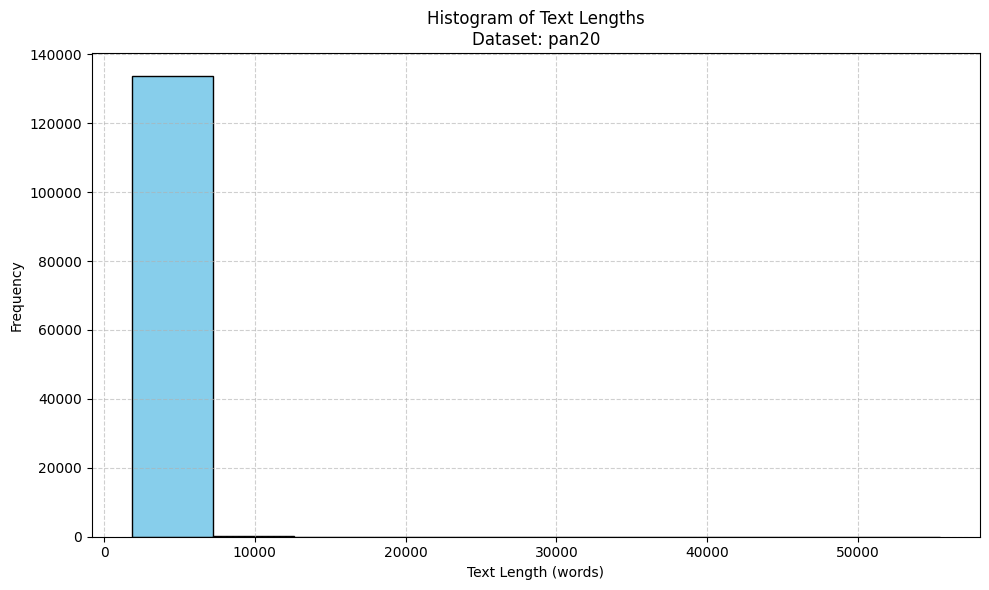

Average length (characters) per text: 3914.87


In [18]:
pan20.plot_text_length_histogram(dataset=ds_pan20, preprocess_fn=_split, unit="words")

The shortest PAN20 text (505 words) does not really make sense.

In [19]:
print_min_len_text_sample(ds_pan20)

Text with minimal length 1874:
"It is truly an honor to serve you the good people of Venice, you cittadini of Italy. It is thanks
to you that I do this now. You see each of you is here for a reason. You each bring something of
great value to Italy, whether you are men of power, women, or sons of greats." He locked eyes with
Demitri "Sons of warriors." He moved his eyes over the crowd again "I want each of you to know it is
for these reasons that my actions are dictated... Guards!" Suddenly men in armor with blades drawn
leapt from the shadows. Where no one had stood suddenly there were dozens of soldiers. The crowd
gasped, and a woman screamed. "Each of you is of great power, and is somehow linked to an enemy of
the state!" Basto announced strongly "So it has been dictated by your great governor Tarrini
Montague that each of you are to be executed. I apologize, but I decided to give you a big send
off." Suddenly fireworks shot into the sky "Do not worry the city of Venice shall be awok

The longest PAN20 text (55,406 words) seems to be a book with multiple chapters.

In [20]:
print_max_len_text_sample(ds_pan20)

Text with maximal length 55406:
Chapter 1 The sun had risen on their last day in the port of Sinjai, the final destination before
returning to Basra with the sultan Omar"s supplies. There would be a late tide so Sinbad gave shore
leave to all but himself and 3 members of the crew with orders to have fun but return in shape to
weigh anchor at the evening"s high tide. Firouz decided to remain on board as well. He had been
working on some experiments that needed his undivided attention. Garret was in charge of the cargo.
He had to itemize the sultan"s wares. The other two crewmen were young and wet behind the ears. They
had come aboard in Basra and were too excited to be a part of Sinbad"s crew to care about shore
leave. They had offered to help Garret in exchange for some sparring against the captain"s sword.
Sinbad had learned to fight in a similar manner and in fact, was honored that they felt his skills
where worth losing a day of shore leave. Unlike Sinbad however, who was new at the

In [21]:
# labels_pan20.value_counts()

In [22]:
pan20_stats = pan20.dataset_stats()

In [23]:
# pan20.plot_text_length_histogram(bins=50)

In [24]:
# def normalize_text(text):
#     stemmer = SnowballStemmer('english')
#     return ' '.join(stemmer.stem(w) for w in text.lower().split())

In [25]:
# FIXME: kernel fails

# impostor_det = ImpostorDetector(ds_pan, top_n=250, portion_delete=0.5, shared_vocab_only=True)

# preproc_fn = partial(impostor_det.tokenize_char_ngrams, n=4, normalize_ws=True, space_free=True)
# pan20.plot_text_length_histogram(bins=50, preprocess_fn=preproc_fn)

In [26]:
# pan20.plot_avg_text_length_per_author()

In [27]:
# pan20.plot_avg_text_length_per_author(unit='ngrams')

In [28]:
# pan20.boxplots_text_len_ngrams()

In [29]:
# Python garbage collector to release memory
del pan20
gc.collect()

3754

## Blog Corpus

In [30]:
blog = datasets.BlogVisualization()

In [31]:
ds_blog = blog.load_dataset()

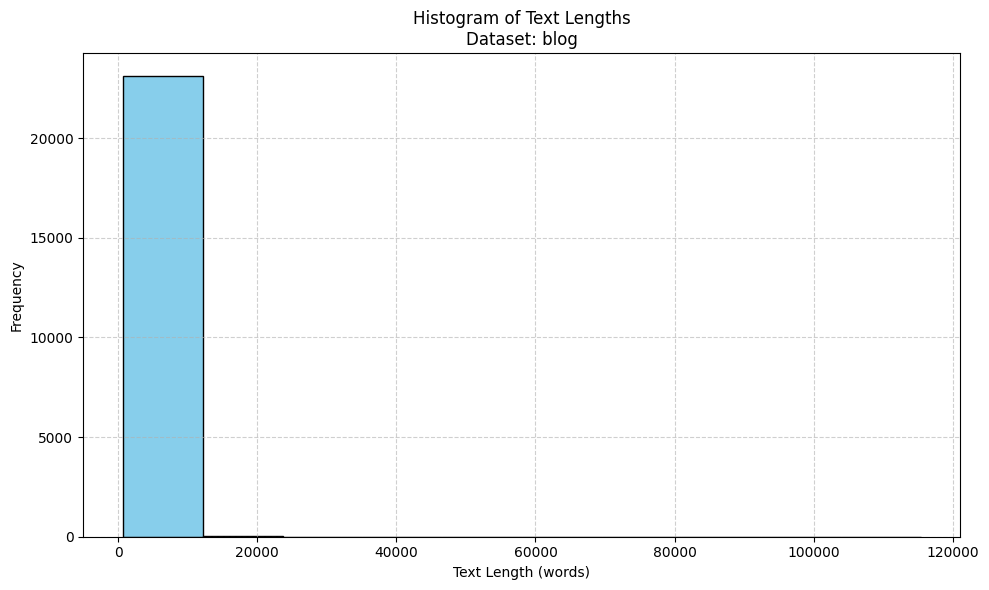

Average length (characters) per text: 1154.73


In [32]:
blog.plot_text_length_histogram(dataset=ds_blog, preprocess_fn=_split, unit="words")

The shortest blog text (500 words) is an experience report from a McLachlan concert.

In [33]:
print_min_len_text_sample(ds_blog)

Text with minimal length 700:
This weekend was lame. Jodi worked both days, so that pretty much blows anything that I want to do
out of the water since she works shifts that occupy all of the daylight hours. Other than that, I
cut the tip of my thumb off. Total rookie moove too. I was chopping some onions, while trying to
melt some butter and I needed to work on the dish washer (the latch mechanism wasn't functioning
properly). So while I'm thinking about that... my stupid self goes and nips the tip of my thumb...
bleeding ensues... Jodi watches. I had to have her finish cutting the onion... but was kind of
annoyed that I actually had to ask her. Here I am will blood starting to run down my hand... oh
well, after that she took care of me. She put a special 'finger cuff' style bandaid on it. I like
'em, they make my finger look kind of like a little nun (it stays open on one side, so the bandaid
looks like a head cover). Anyway, I started reading Harry Potter: The Goblet of Fire. I'm ab

The longest Blog entry (8663 words) seems to be a fictional book/ story.

In [34]:
print_max_len_text_sample(ds_blog)

Text with maximal length 11857:
192 IONITCH by Anton Chekhov I WHEN visitors to the provincial town S---- complained of the
dreariness and monotony of life, the inhabitants of the town, as though defending themselves,
declared that it was very nice in S----, that there was a library, a theatre, a club; that they had
balls; and, finally, that there were clever, agreeable, and interesting families with whom one could
make acquaintance. And they used to point to the family of the Turkins as the most highly cultivated
and talented. This family lived in their own house in the principal street, near the Governor's.
Ivan Petrovitch Turkin himself -- a stout, handsome, dark man with whiskers -- used to get up
amateur performances for benevolent objects, and used to take the part of an elderly general and
cough very amusingly. He knew a number of anecdotes, charades, proverbs, and was fond of being
humorous and witty, and he always wore an expression from which it was impossible to tell whether

In [35]:
blog_stats = blog.dataset_stats()

In [36]:
blog_df = pd.read_csv(
    Path(os.getcwd()).resolve().parent / "data/datasets/Blog_corpus/blogtext.csv"
)
blog_df["date"] = pd.to_datetime(
    blog_df["date"], format="mixed", dayfirst=True, errors="coerce"
)
print(blog_df["date"].agg(["min", "max"]))
print(
    "there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it"
)

min   1999-01-01
max   2006-08-23
Name: date, dtype: datetime64[ns]
there is actually entries with date= 01,January,1999 and 23,August,2006, i checked it


In [37]:
from itertools import chain


# num_words = [len(text.split()) for text in chain.from_iterable(blog_df['pair'])]
print(blog_df.columns)
one_word_rows = blog_df[blog_df["text"].apply(lambda x: len(x.split()) == 1)]
print(f"Number of rows with one word in 'text': {len(one_word_rows)}")
print("Rows with one word in 'text':")
print(one_word_rows[["text", "date", "id"]].head(10))
print(
    "Stats are calculated on the arrow dataset, where entries must have at least 500 words, so these entries are not included in the stats."
)

Index(['id', 'gender', 'age', 'topic', 'sign', 'date', 'text'], dtype='object')
Number of rows with one word in 'text': 4276
Rows with one word in 'text':
                                                   text       date       id
1163                                             URGH   2004-08-12  1932521
1441                                     baak?          2004-08-05   589736
1543                                     niort          2004-08-05   589736
1595                                    quack.          2004-08-05   589736
1619                              TGIF!!!!!!!           2004-08-05   589736
1621                                     FLORA          2004-08-05   589736
1680                                  hmmm....          2004-08-05   589736
1719                                  marzipan          2004-08-05   589736
1737             NIORT!!!!!!!!!!!!!!!!!!!!!!!!!!!!! ... 2004-08-05   589736
1760                                       aye          2004-08-05   589736
Stats are

In [38]:
# blog.plot_avg_text_length_per_author()    # too many authors
# blog.plot_text_length_histogram(bins=50)  # FIXME: dataset comes already preprocessed
# blog.boxplots_text_len_ngrams()

In [39]:
# Python garbage collector to release memory
del blog
gc.collect()

3498

## Gutenberg

In [40]:
gutenberg = datasets.GutenbergVisualization()

In [41]:
ds_gutenberg = gutenberg.load_dataset()

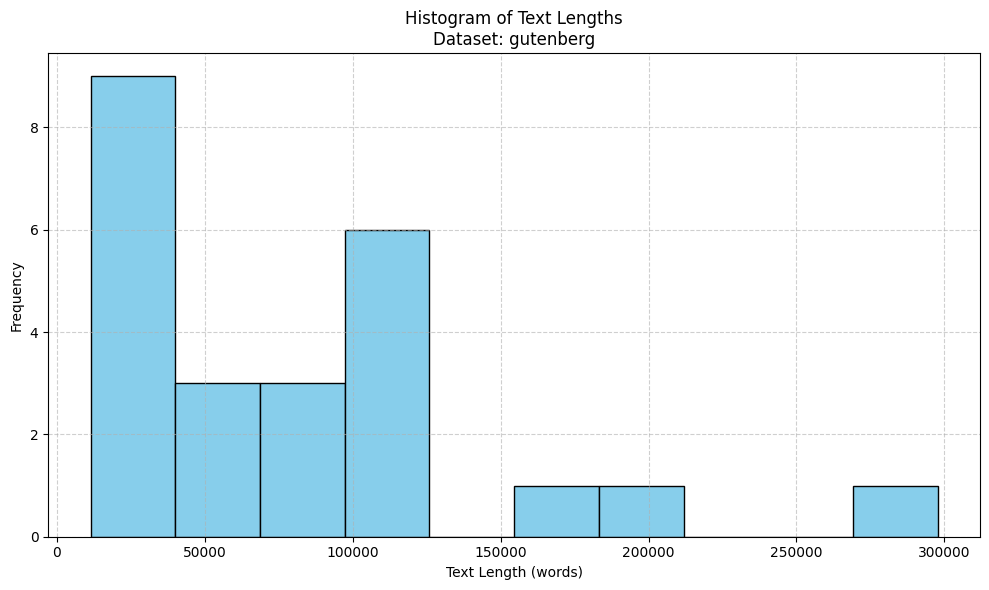

Average length (characters) per text: 78701.50


In [42]:
gutenberg.plot_text_length_histogram(
    dataset=ds_gutenberg, preprocess_fn=_split, unit="words"
)

In [43]:
print_min_len_text_sample(ds_gutenberg)

Text with minimal length 11443:
When Mr. Hiram B. Otis, the American Minister, bought Canterville Chase, every one told him he was
doing a very foolish thing, as there was no doubt at all that the place was haunted. Indeed, Lord
Canterville himself, who was a man of the most punctilious honour, had felt it his duty to mention
the f Mr. Otis when they came to discuss terms. "We have not cared to live in the place ourselves,"
said Lord Canterville, "since my grandaunt, the Dowager Duchess of Bolton, was frightened into a
fit, from which she never really recovered, by two skeleton hands being placed on her shoulders as
she was dressing for dinner, and I feel bound to tell you, Mr. Otis, that the ghost has been seen by
several living members of my family, as well as by the rector of the parish, the Rev. Augustus
Dampier, who is a Fellow of King's College, Cambridge. After the unfortunate accident to the
Duchess, none of our younger servants would stay with us, and Lady Canterville often go

In [44]:
print_max_len_text_sample(ds_gutenberg)

Text with maximal length 157277:
Emma Woodhouse, handsome, clever, and rich, with a comfortable home and happy disposition, seemed to
unite some of the best blessings of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her. She was the youngest of the two daughters of a most
affectionate, indulgent father; and had, in consequence of her sisters marriage, been mistress of
his house from a very early period. Her mother had died too long ago for her to have more than an
indistinct remembrance of her caresses; and her place had been supplied by an excellent woman as
governess, who had fallen little short of a mother in affection. Sixteen years had Miss Taylor been
in Mr. Woodhouses family, less as a governess than a friend, very fond of both daughters, but
particularly of Emma. Between them it was more the intimacy of sisters. Even before Miss Taylor had
ceased to hold the nominal office of governess, the mildness of her temper had hardly al

Preprocessing example on MacBeth

In [45]:
imp_det = ImpostorDetector()
# sample_text = ds_gutenberg['pair'].iloc[0][0]
sys.path.append(os.path.abspath(".."))

with open(
    Path(os.getcwd()).resolve().parent
    / Path(CONFIG.PATH2GUTENBERG).parent
    / "Macbeth_William_Shakespeare.txt",
    "r",
) as f:
    sample_text = f.read()
print(textwrap.fill(sample_text, width=80))

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


ACT I  SCENE I. An open Place.    Thunder and Lightning. Enter three Witches.
FIRST WITCH. When shall we three meet again? In thunder, lightning, or in rain?
SECOND WITCH. When the hurlyburly’s done, When the battle’s lost and won.  THIRD
WITCH. That will be ere the set of sun.  FIRST WITCH. Where the place?  SECOND
WITCH. Upon the heath.  THIRD WITCH. There to meet with Macbeth.  FIRST WITCH. I
come, Graymalkin!  SECOND WITCH. Paddock calls.  THIRD WITCH. Anon.  ALL. Fair
is foul, and foul is fair: Hover through the fog and filthy air.   [_Exeunt._]
SCENE II. A Camp near Forres.   Alarum within. Enter King Duncan, Malcolm,
Donalbain, Lennox, with  Attendants, meeting a bleeding Captain.  DUNCAN. What
bloody man is that? He can report, As seemeth by his plight, of the revolt The
newest state.  MALCOLM. This is the sergeant Who, like a good and hardy soldier,
fought ’Gainst my captivity.—Hail, brave friend! Say to the King the knowledge
of the broil As thou didst leave it.  SOLDIER. Dou

In [46]:
normalized_text = imp_det.preprocess_text(sample_text)
print(textwrap.fill(normalized_text, width=80))

An open Place. Thunder and Lightning. Enter three Witches. When shall we three
meet again? In thunder, lightning, or in rain? When the hurlyburlys done, When
the battles lost and won. That will be ere the set of sun. Where the place? Upon
the heath. There to meet with Macbeth. I come, Graymalkin! Paddock calls. Anon.
Fair is foul, and foul is fair: Hover through the fog and filthy air. Exeunt. A
Camp near Forres. Alarum within. Enter King Duncan, Malcolm, Donalbain, Lennox,
with Attendants, meeting a bleeding Captain. What bloody man is that? He can
report, As seemeth by his plight, of the revolt The newest state. This is the
sergeant Who, like a good and hardy soldier, fought Gainst my captivity.Hail,
brave friend! Say to the King the knowledge of the broil As thou didst leave it.
Doubtful it stood; As two spent swimmers that do cling together And choke their
art. The merciless Macdonwald (Worthy to be a rebel, for to that The multiplying
villainies of nature Do swarm upon him) from t

In [47]:
gutenberg_stats = gutenberg.dataset_stats()

In [48]:
# gutenberg.plot_avg_text_length_per_author()
# gutenberg.plot_text_length_histogram(bins=50)
# gutenberg.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del gutenberg
# gc.collect()

## PAN 25

In [49]:
# pan25 = datasets.Pan25Visualization()
# pan25_stats = pan25.dataset_stats()

## Webis Koppel dataset

In [50]:
# koppel_webis = datasets.KoppelWebisVisualization()
# koppel_webis_stats = koppel_webis.dataset_stats()

In [51]:
# koppel_webis.plot_avg_text_length_per_author()
# koppel_webis.plot_text_length_histogram(bins=50)
# koppel_webis.boxplots_text_len_ngrams()

# # Python garbage collector to release memory
# del koppel_webis
# gc.collect()

## Compare datasets

In [52]:
combined_stats = pd.concat(
    [
        pan20_stats,
        blog_stats,
        gutenberg_stats,
        student_essays_stats,
        # pan23_stats, koppel_webis_stats, # pan25_stats
    ],
    axis=0,
    ignore_index=True,
)  # concat rows
combined_stats.set_index("dataset", inplace=True)  # set dataset as index
save_path = Path.cwd().parent / CONFIG.SAVE_PATH / "all_data" / "statistics"
save_path.mkdir(parents=True, exist_ok=True)  # create directory if it doesn't exist
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
combined_stats.to_csv(
    save_path / f"combined_stats_{timestamp}.csv", float_format="%.2f"
)
print(f"Combined statistics saved to {save_path / f'combined_stats_{timestamp}.csv'}")

Combined statistics saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/all_data/statistics/combined_stats_20250727_212251.csv


In [53]:
display(combined_stats)

,num_pairs,num_authors,num_same_pairs,num_different_pairs,avg_text_len_chars,min_text_len_chars,max_text_len_chars,std_text_len_chars,avg_text_len_words,min_text_len_words,max_text_len_words,std_text_len_words,median_text_len_words
dataset,,,,,,,,,,,,,
pan20,66905,52771,35616,31289,21418.76,11742,296734,2682.09,3914.76,1874,55413,512.19,3889
blog,11565,5997,6204,5361,6249.94,3141,615409,8088.16,1154.25,700,115365,1493.97,913
gutenberg,12,7,6,6,437870.75,63938,1696684,387405.67,78698.79,11443,297704,68329.91,60282
student_essays,224,222,112,112,4459.32,3435,8119,805.14,865.90,700,1634,157.41,815
